In [23]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Dropout, Conv2D, MaxPool2D, Dense, Flatten
from keras.optimizers import AdamW
from keras.losses import SparseCategoricalCrossentropy

import numpy as np
import matplotlib.pyplot as plt

import os

In [4]:
data_path = "/mnt/c/Users/Mousavi/Downloads/5_flowers"

batch_size = 16
image_height, image_width = (512, 512)

In [5]:
train_loader = tf.keras.utils.image_dataset_from_directory(data_path, 
                                                           validation_split=0.2, 
                                                           image_size=(image_height, image_width), 
                                                           seed=42, 
                                                           subset='training', 
                                                           batch_size=batch_size
                                                           )

val_loader = tf.keras.utils.image_dataset_from_directory(data_path, 
                                                           validation_split=0.2, 
                                                           image_size=(image_height, image_width), 
                                                           seed=42, 
                                                           subset='validation',
                                                           shuffle=False, 
                                                           batch_size=batch_size
                                                           )

Found 5019 files belonging to 5 classes.
Using 4016 files for training.


W0000 00:00:1777093889.528533  335348 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 5019 files belonging to 5 classes.
Using 1003 files for validation.


In [7]:
class_names = train_loader.class_names
class_names

['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']

In [11]:
for images, labels in train_loader.take(1):
    print(f"Shape of images: {images.shape}")
    print(f"Shape of labels: {labels.shape}")

Shape of images: (16, 512, 512, 3)
Shape of labels: (16,)


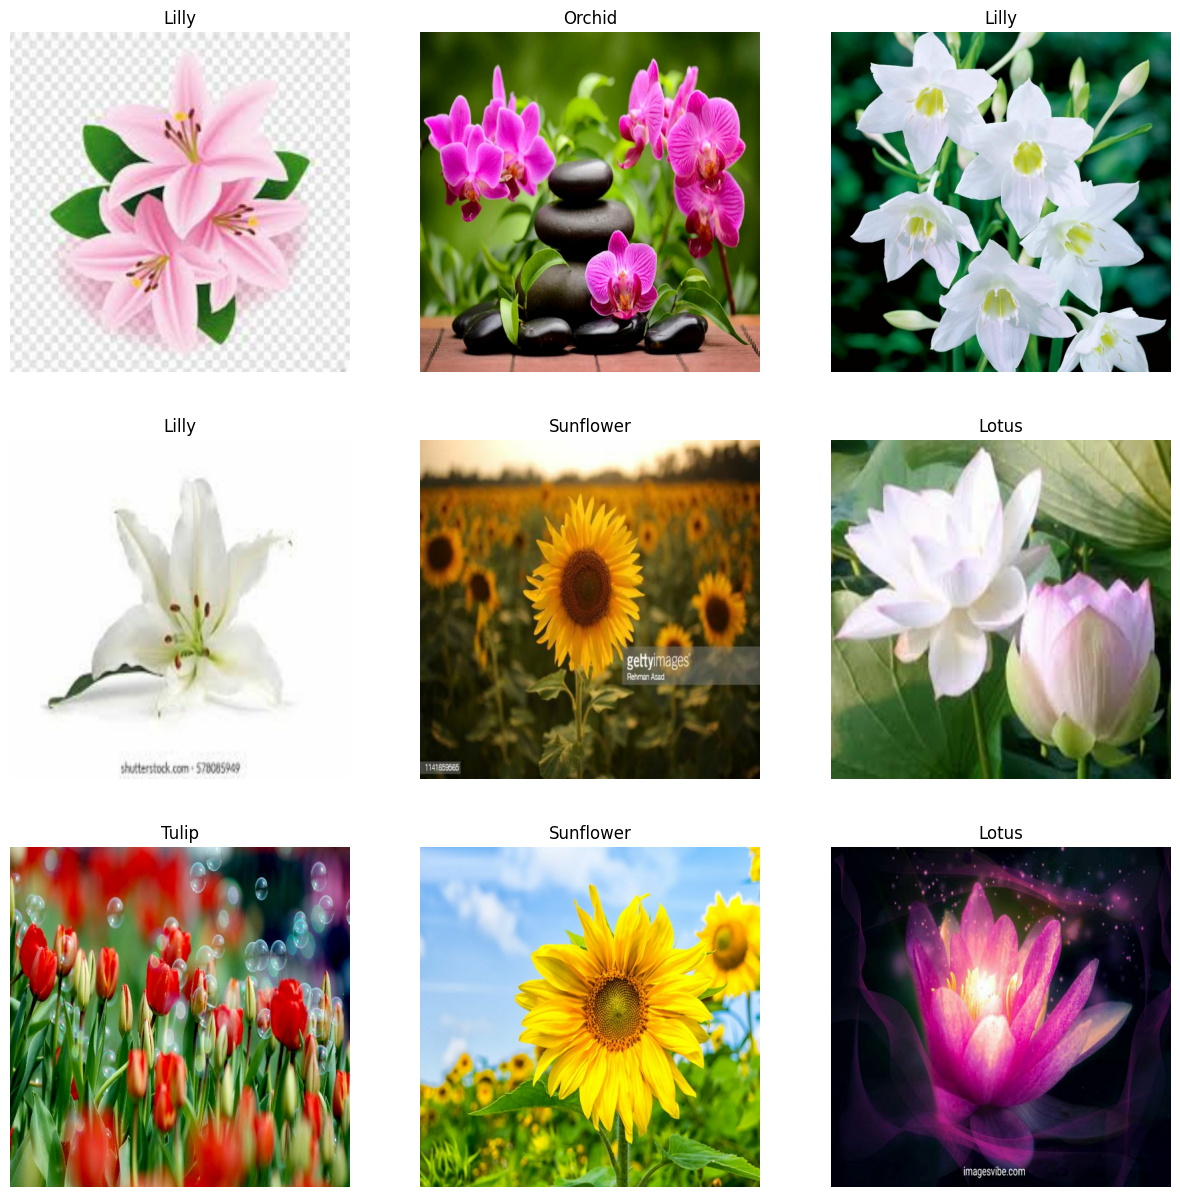

In [13]:
plt.figure(figsize=(15, 15))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().astype(np.uint8))
    plt.title(class_names[labels[i].numpy()])
    plt.axis('off')

## Normalization

In [17]:
# On CPU
normalization_layer = tf.keras.layers.Rescaling(1./255)   # Between (0, 1)

train_loader_norm = train_loader.map(lambda x, y: (normalization_layer(x), y))
val_loader_norm = val_loader.map(lambda x, y: (normalization_layer(x), y))

images, labels = next(iter(train_loader_norm))
image = images[0]

print(f"Min of intensity in image is: {image.numpy().min()} and Max of intensity is: {image.numpy().max()}")

Min of intensity in image is: 0.0 and Max of intensity is: 1.0


# Cache and prefetch

In [19]:
train_loader_norm = train_loader_norm.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_loader_norm = val_loader_norm.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

## Create the Model

In [24]:
model = Sequential()
model.add(keras.layers.Input((512, 512, 3)))
# model.add(keras.layers.Rescaling(1./255))     # Rescaled on cpu befor

model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D())

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(Dense(5))


In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 510, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 124, 124, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,547,141 (120.34 MB)

 Trainable params: 31,547,141 (120.34 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer=AdamW(learning_rate=1e-3),
              loss=SparseCategoricalCrossentropy(from_logits=True), 
              metrics=['accuracy']
              )

In [27]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.21.0
GPU devices: []


In [28]:
history = model.fit(train_loader_norm,
                    epochs=2,
                    validation_data=val_loader_norm)

Epoch 1/2


: 